<h1 style="color:#1E90FF; text-align:center; font-family:Arial, sans-serif;">
  Eye Disease Classification with DenseNet121
</h1>


<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  Import Libraries
</h3>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import random 
import shutil
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D  
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import classification_report,confusion_matrix

 

2026-02-19 03:43:27.071965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771472607.259637      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771472607.317631      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771472607.759997      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771472607.760036      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771472607.760039      24 computation_placer.cc:177] computation placer alr

<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  Read Data & split in train,val,test
</h3>


In [2]:
dataset_path="/kaggle/input/eye-diseases-classification/dataset"
output_path="dataset_split" 

train_ratio=0.8
val_ratio=0.1
test_ratio=0.1

os.makedirs(output_path,exist_ok=True)
for split in ["train","val","test"]:
    os.makedirs(os.path.join(output_path,split),exist_ok=True)

In [3]:
classes=os.listdir(dataset_path)

for cls in classes:
    cls_path=os.path.join(dataset_path,cls)
    images=os.listdir(cls_path)
    random.shuffle(images)
    n_total=len(images)
    n_train=int(n_total*train_ratio)
    n_val=int(n_total*val_ratio)
    n_test=n_total-n_train-n_val
    for split,imgs in zip(["train","val","test"],[images[:n_train],images[n_train:n_train+n_val],images[n_train+n_val:]]):
        split_cls_dir=os.path.join(output_path,split,cls)
        os.makedirs(split_cls_dir,exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(cls_path,img),os.path.join(split_cls_dir,img))
    

In [4]:
IMG_H=224
IMG_W=224
BATCH_SIZE=32

In [5]:
train_ds=image_dataset_from_directory(
    os.path.join(output_path,'train'),
    image_size=(IMG_H,IMG_W),
    batch_size=BATCH_SIZE
)
val_ds=image_dataset_from_directory(
    os.path.join(output_path,'val'),
    image_size=(IMG_H,IMG_W),
    batch_size=BATCH_SIZE
)
test_ds=image_dataset_from_directory(
    os.path.join(output_path,'test'),
    image_size=(IMG_H,IMG_W),
    batch_size=BATCH_SIZE
)

Found 3372 files belonging to 4 classes.


I0000 00:00:1771472659.238523      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771472659.244892      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 419 files belonging to 4 classes.
Found 426 files belonging to 4 classes.


In [6]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  Show Random Sample For Train,Val,Test Before preprocessing 
</h3>


In [7]:
def show_random_samples(datasets,class_names,num_samples=5):
    plt.figure(figsize=(10,5))
    for images,labels in datasets.take(1):
        images=images.numpy()
        labels=labels.numpy()
        indices=np.random.choice(range(len(images)),size=num_samples,replace=False)
        for i,idx in enumerate(indices):
            ax=plt.subplot(1,num_samples,i+1)
            plt.imshow(images[idx].astype("uint8"))
            plt.title(class_names[labels[idx]])
            plt.axis("off")

    plt.show()

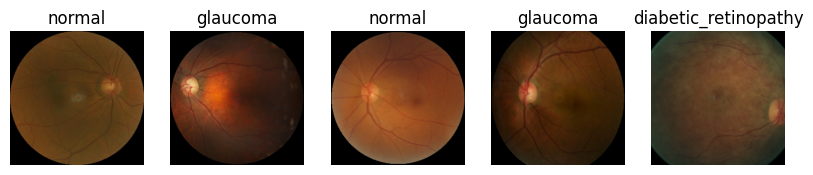

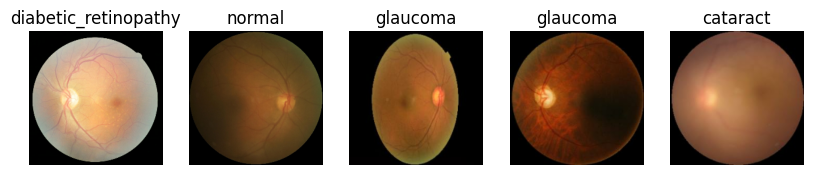

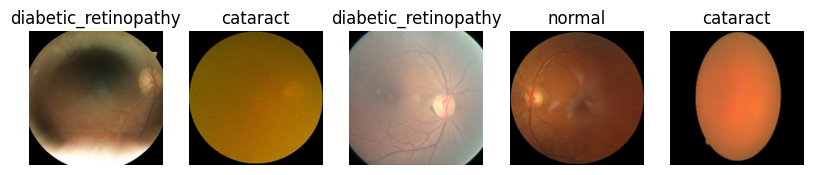

In [8]:
show_random_samples(train_ds, class_names)
show_random_samples(val_ds, class_names)
show_random_samples(test_ds, class_names)

<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  preprocessing The Data 
</h3>


In [9]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
rescale=layers.Rescaling(1.0/255)

In [10]:
train_ds=train_ds.map(lambda x,y:(data_augmentation(x, training=True),y))
train_ds=train_ds.map(lambda x,y:(rescale(x),y))
val_ds=val_ds.map(lambda x,y:(rescale(x),y))
test_ds=test_ds.map(lambda x,y:(rescale(x),y))

<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  Show Data After preprocessing
</h3>


In [11]:
def show_random_samples(datasets,class_names,num_samples=5):
    plt.figure(figsize=(10,5))
    for images,labels in datasets.take(1):
        images=images.numpy()
        labels=labels.numpy()
        indices=np.random.choice(range(len(images)),size=num_samples,replace=False)
        for i,idx in enumerate(indices):
            ax=plt.subplot(1,num_samples,i+1)
            plt.imshow(images[idx])
            plt.title(class_names[labels[idx]])
            plt.axis("off")

    plt.show()

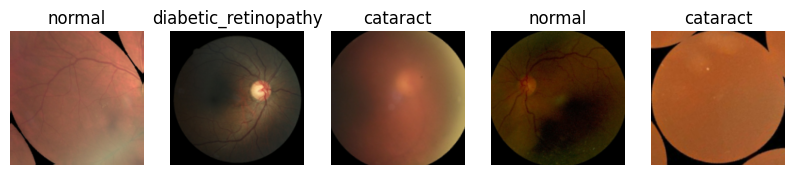

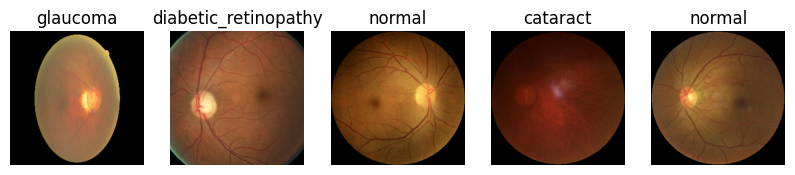

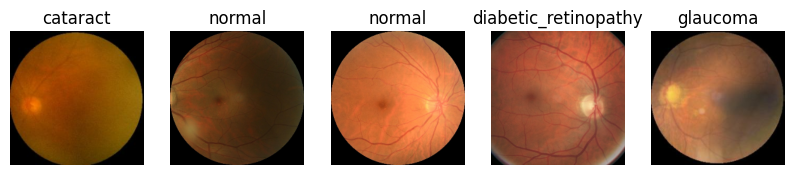

In [12]:
show_random_samples(train_ds, class_names)
show_random_samples(val_ds, class_names)
show_random_samples(test_ds, class_names)

<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  Check Data Balance
</h3>


In [13]:
split = "train"
split_path = os.path.join(output_path, split)

class_names = []
num_images = []

for cls in os.listdir(split_path):
    cls_path = os.path.join(split_path, cls)
    n = len(os.listdir(cls_path))
    class_names.append(cls)
    num_images.append(n)

/tmp/ipykernel_24/3984272116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=num_images, palette="viridis")


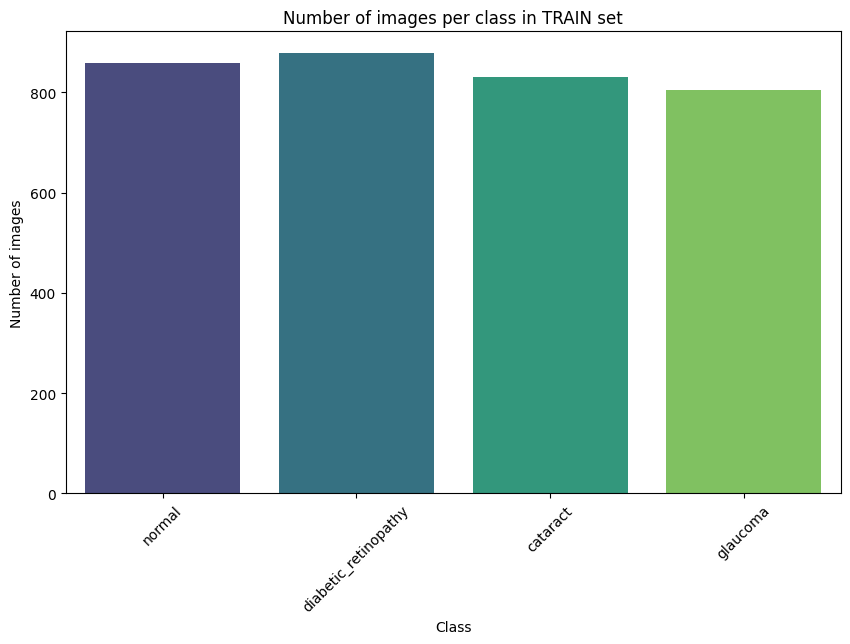

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=num_images, palette="viridis")
plt.title("Number of images per class in TRAIN set")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()


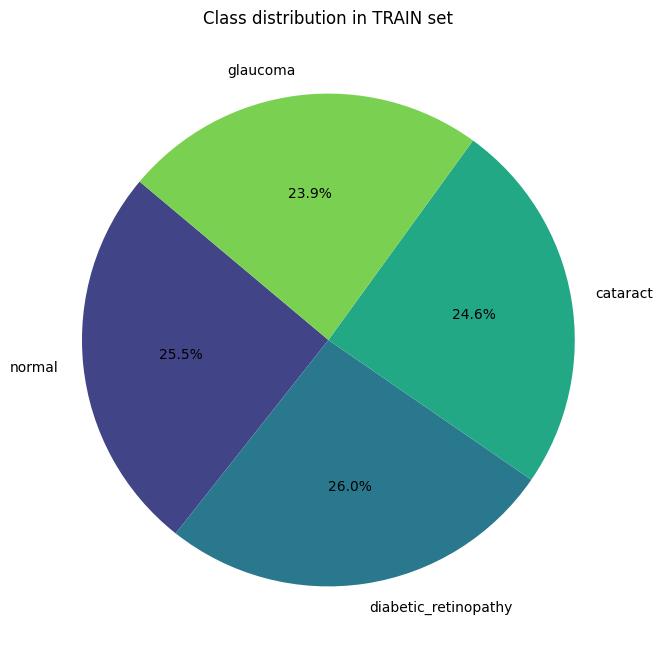

In [15]:
plt.figure(figsize=(8,8))
plt.pie(num_images, labels=class_names, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("viridis", len(class_names)))
plt.title("Class distribution in TRAIN set")
plt.show()

<h3 style="color:#FF4500; font-family:Verdana, sans-serif; border-bottom:2px solid #FF4500; padding-bottom:5px;">
  load DenseNet121
</h3>


In [16]:
base_model=DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_H,IMG_W,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<h4 style="color:#E83C91; font-family:Verdana, sans-serif; margin-top:8px;">
  ➤ Feature Extractor
</h4>


In [17]:

base_model.trainable=False
model=models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64,activation='relu'),
    layers.Dense(4,activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
epoch=10
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epoch
)

Epoch 1/10


I0000 00:00:1771472681.849270      76 service.cc:152] XLA service 0x7f9938013d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771472681.849317      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771472681.849322      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771472685.407779      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/106 ━━━━━━━━━━━━━━━━━━━━ 48:48 28s/step - accuracy: 0.3438 - loss: 2.1036

I0000 00:00:1771472696.808199      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


106/106 ━━━━━━━━━━━━━━━━━━━━ 100s 686ms/step - accuracy: 0.5953 - loss: 0.9406 - val_accuracy: 0.6897 - val_loss: 0.7442
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 377ms/step - accuracy: 0.8008 - loss: 0.5395 - val_accuracy: 0.7327 - val_loss: 0.6411
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 373ms/step - accuracy: 0.8280 - loss: 0.4536 - val_accuracy: 0.7589 - val_loss: 0.6573
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 372ms/step - accuracy: 0.8359 - loss: 0.4386 - val_accuracy: 0.7566 - val_loss: 0.5936
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 372ms/step - accuracy: 0.8389 - loss: 0.4100 - val_accuracy: 0.7375 - val_loss: 0.6415
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 376ms/step - accuracy: 0.8485 - loss: 0.3987 - val_accuracy: 0.7947 - val_loss: 0.5428
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 371ms/step - accuracy: 0.8636 - loss: 0.3519 - val_accuracy: 0.7780 - val_loss: 0.5576
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 369ms/step - accuracy: 0.8715 - loss: 0.3468 - va

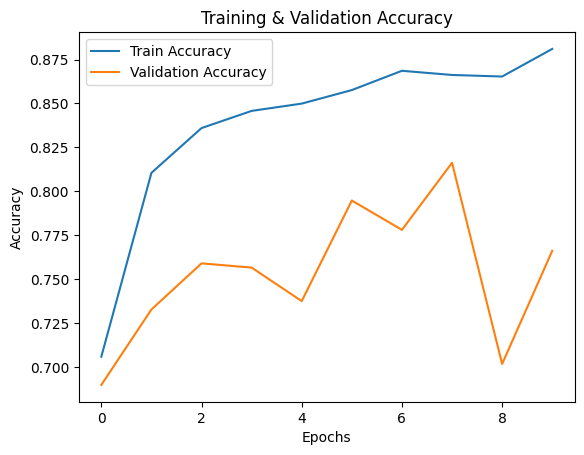

In [18]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.show()


<h4 style="color:#E83C91; font-family:Verdana, sans-serif; margin-top:8px;">
  ➤ Feature Extractor Evaluation
</h4>


In [19]:
train_loss,train_acc=model.evaluate(train_ds)
print(f"Train Accuracy: {train_acc*100:.2f}%")
test_loss,test_acc=model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

106/106 ━━━━━━━━━━━━━━━━━━━━ 46s 432ms/step - accuracy: 0.8754 - loss: 0.3305
Train Accuracy: 88.23%
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 881ms/step - accuracy: 0.7667 - loss: 0.6578
Test Accuracy: 78.64%


In [20]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs)   
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [21]:
print("Classification Report:\n")
print(classification_report(y_true,y_pred,target_names=class_names))

Classification Report:

                      precision    recall  f1-score   support

              normal       0.94      0.77      0.85       105
diabetic_retinopathy       0.68      0.99      0.81       111
            cataract       0.82      0.72      0.76       102
            glaucoma       0.80      0.66      0.72       108

            accuracy                           0.79       426
           macro avg       0.81      0.78      0.78       426
        weighted avg       0.81      0.79      0.78       426



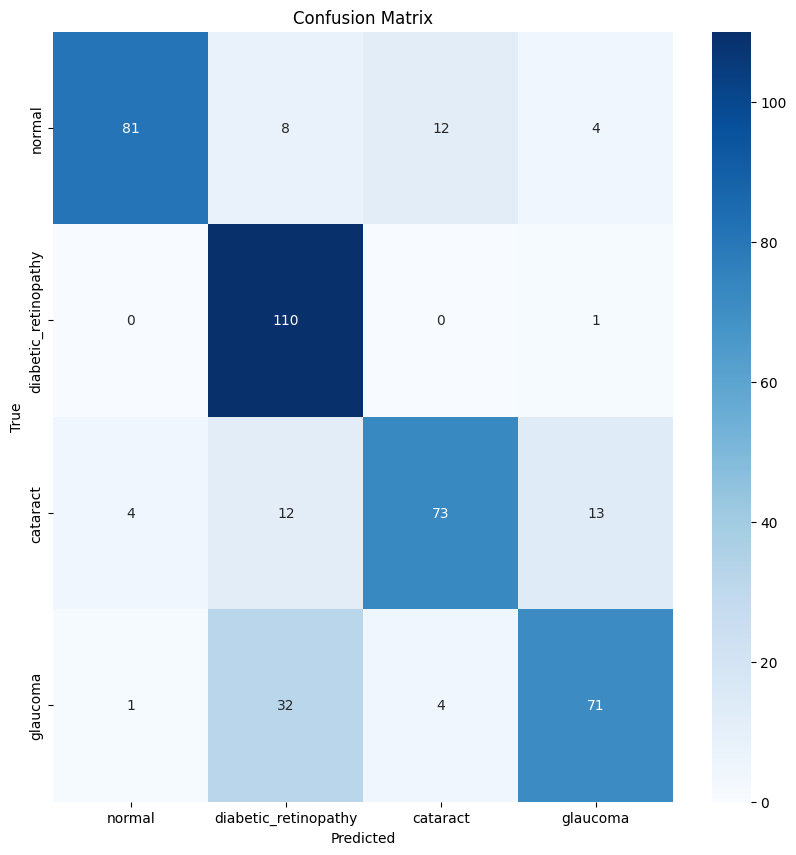

In [22]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

<h4 style="color:#E83C91; font-family:Verdana, sans-serif; margin-top:8px;">
  ➤ Partial Fine-Tuning
</h4>


In [23]:
base_model.trainable = True 
fine_tune_at = 300
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(4, activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 146s 837ms/step - accuracy: 0.6446 - loss: 1.0767 - val_accuracy: 0.7351 - val_loss: 0.7335
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 367ms/step - accuracy: 0.8764 - loss: 0.3328 - val_accuracy: 0.8425 - val_loss: 0.4488
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 370ms/step - accuracy: 0.9160 - loss: 0.2333 - val_accuracy: 0.8568 - val_loss: 0.4108
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 370ms/step - accuracy: 0.9254 - loss: 0.2071 - val_accuracy: 0.8950 - val_loss: 0.3716
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 362ms/step - accuracy: 0.9389 - loss: 0.1806 - val_accuracy: 0.9332 - val_loss: 0.2267
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 364ms/step - accuracy: 0.9504 - loss: 0.1496 - val_accuracy: 0.9165 - val_loss: 0.2843
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 360ms/step - accuracy: 0.9526 - loss: 0.1364 - val_accuracy: 0.9165 - val_loss: 0.2937
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 364ms/step - accuracy: 0.9637 - loss: 

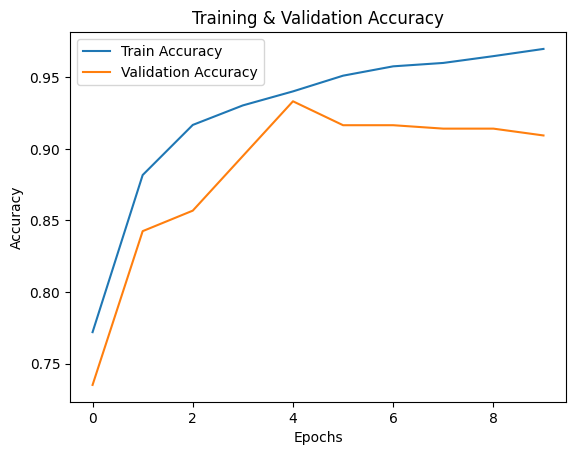

In [24]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.show()


<h4 style="color:#E83C91; font-family:Verdana, sans-serif; margin-top:8px;">
  ➤ Partial Fine-Tuning Evaluation 
</h4>


In [25]:
train_loss,train_acc=model.evaluate(train_ds)
print(f"Train Accuracy: {train_acc*100:.2f}%")
test_loss,test_acc=model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

106/106 ━━━━━━━━━━━━━━━━━━━━ 46s 434ms/step - accuracy: 0.9773 - loss: 0.0610
Train Accuracy: 98.16%
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 687ms/step - accuracy: 0.9247 - loss: 0.2135
Test Accuracy: 92.49%


In [26]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs)   
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [27]:
print("Classification Report:\n")
print(classification_report(y_true,y_pred,target_names=class_names))

Classification Report:

                      precision    recall  f1-score   support

              normal       0.98      0.92      0.95       105
diabetic_retinopathy       0.99      0.97      0.98       111
            cataract       0.92      0.85      0.88       102
            glaucoma       0.83      0.94      0.88       108

            accuracy                           0.92       426
           macro avg       0.93      0.92      0.92       426
        weighted avg       0.93      0.92      0.93       426



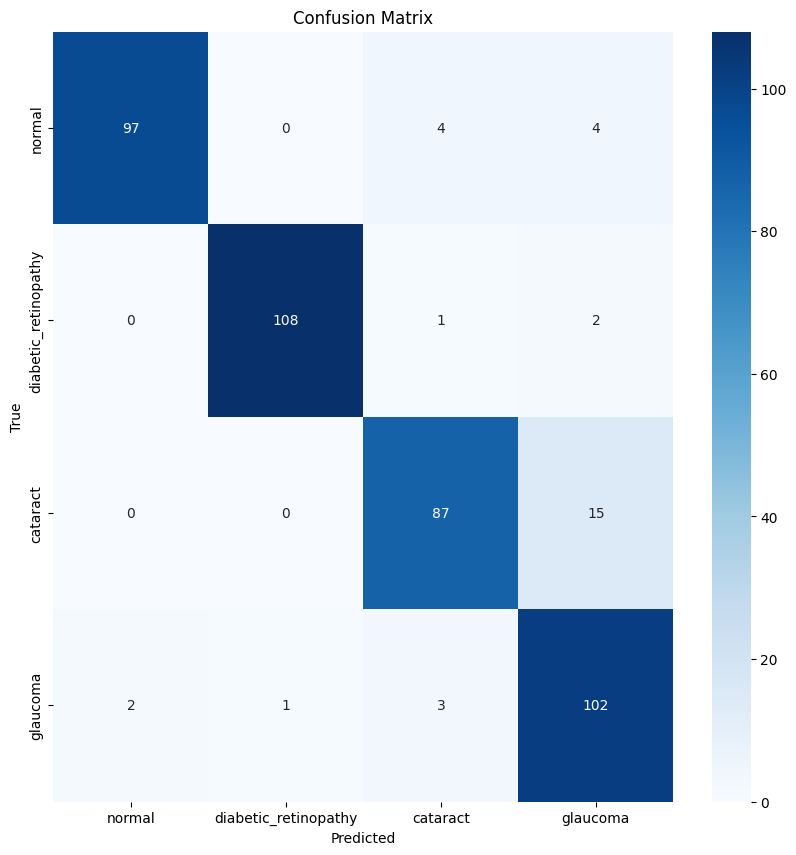

In [28]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

<h4 style="color:#E83C91; font-family:Verdana, sans-serif; margin-top:8px;">
  ➤ Full Fine-Tuning
</h4>


In [29]:

base_model.trainable = True  

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 144s 832ms/step - accuracy: 0.3151 - loss: 1.7442 - val_accuracy: 0.7685 - val_loss: 0.6965
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 373ms/step - accuracy: 0.8459 - loss: 0.5095 - val_accuracy: 0.8496 - val_loss: 0.4397
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.9081 - loss: 0.3252 - val_accuracy: 0.8831 - val_loss: 0.3620
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 374ms/step - accuracy: 0.9207 - loss: 0.2735 - val_accuracy: 0.8902 - val_loss: 0.3295
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 366ms/step - accuracy: 0.9279 - loss: 0.2204 - val_accuracy: 0.8974 - val_loss: 0.3160
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 364ms/step - accuracy: 0.9441 - loss: 0.1847 - val_accuracy: 0.9141 - val_loss: 0.2941
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 369ms/step - accuracy: 0.9459 - loss: 0.1713 - val_accuracy: 0.9141 - val_loss: 0.2848
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 373ms/step - accuracy: 0.9512 - loss: 

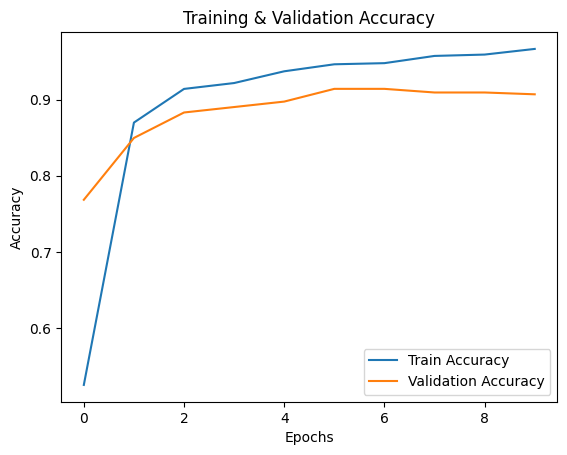

In [30]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.show()


<h4 style="color:#E83C91; font-family:Verdana, sans-serif; margin-top:8px;">
  ➤ Full Fine-Tuning Evaluation
</h4>


In [31]:
train_loss,train_acc=model.evaluate(train_ds)
print(f"Train Accuracy: {train_acc*100:.2f}%")
test_loss,test_acc=model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

106/106 ━━━━━━━━━━━━━━━━━━━━ 47s 440ms/step - accuracy: 0.9755 - loss: 0.0932
Train Accuracy: 97.78%
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 725ms/step - accuracy: 0.9389 - loss: 0.2599
Test Accuracy: 92.72%


In [32]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model.predict(imgs)   
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [33]:
print("Classification Report:\n")
print(classification_report(y_true,y_pred,target_names=class_names))

Classification Report:

                      precision    recall  f1-score   support

              normal       0.95      0.95      0.95       105
diabetic_retinopathy       1.00      0.97      0.99       111
            cataract       1.00      0.78      0.88       102
            glaucoma       0.80      0.99      0.89       108

            accuracy                           0.93       426
           macro avg       0.94      0.93      0.93       426
        weighted avg       0.94      0.93      0.93       426



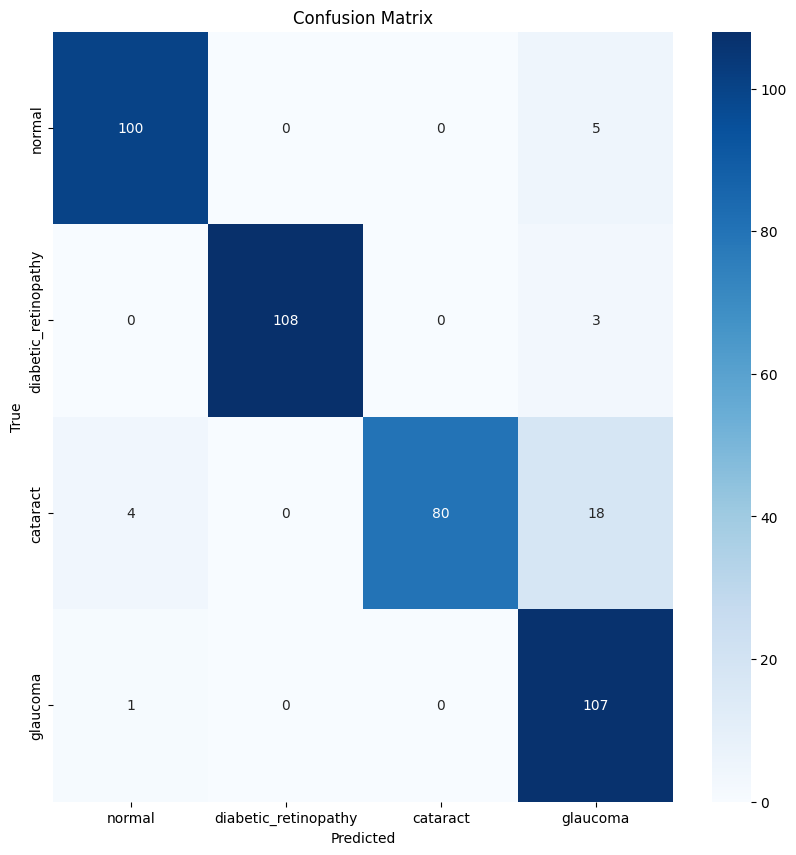

In [34]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()